In [1]:
import zipfile
import os

zip_path = r"C:/Users/tyler/Downloads/walmart-recruiting-store-sales-forecasting.zip"

# List contents of the zip
with zipfile.ZipFile(zip_path, 'r') as z:
    for name in z.namelist():
        print(name)

features.csv.zip
sampleSubmission.csv.zip
stores.csv
test.csv.zip
train.csv.zip


In [3]:
import numpy as np               
import pandas as pd
import datetime as dt   
import matplotlib.pyplot as plt 
import seaborn as sns   
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.preprocessing import LabelEncoder  
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

import xgboost as xgb
import lightgbm as lgb 

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style('whitegrid')

                      
import warnings          
warnings.filterwarnings('ignore')

In [6]:
import pandas as pd
import zipfile
import io

zip_path = r"C:/Users/tyler/Downloads/walmart-recruiting-store-sales-forecasting.zip"

# Load all 3 files directly from inside the zip
with zipfile.ZipFile(zip_path, 'r') as z:
    train    = pd.read_csv(io.BytesIO(z.read('train.csv.zip')), compression='zip')
    features = pd.read_csv(io.BytesIO(z.read('features.csv.zip')), compression='zip')
    stores   = pd.read_csv(io.BytesIO(z.read('stores.csv')))

# Merge train with store metadata
dp_temp = pd.merge(train, stores, on='Store', how='left')

# Drop duplicate IsHoliday column from features before merging
features_clean = features.drop(columns=['IsHoliday'])

# Merge with features on Store and Date
final_dp = pd.merge(dp_temp, features_clean, on=['Store', 'Date'], how='left')

# Convert Date column to datetime format
final_dp['Date'] = pd.to_datetime(final_dp['Date'])

# Fill missing markdown values with 0
final_dp.fillna({
    'MarkDown1': 0, 'MarkDown2': 0, 'MarkDown3': 0, 'MarkDown4': 0, 'MarkDown5': 0
}, inplace=True)

print(f"Original Train Row Count:  {train.shape[0]}")
print(f"Merged Final Row Count:    {final_dp.shape[0]}")
print(f"Column Count:              {final_dp.shape[1]}")
final_dp.head()

Original Train Row Count:  421570
Merged Final Row Count:    421570
Column Count:              16


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.500,False,A,151315,42.310,2.572,0.000,0.000,0.000,0.000,0.000,211.096,8.106
1,1,1,2010-02-12,46039.490,True,A,151315,38.510,2.548,0.000,0.000,0.000,0.000,0.000,211.242,8.106
2,1,1,2010-02-19,41595.550,False,A,151315,39.930,2.514,0.000,0.000,0.000,0.000,0.000,211.289,8.106
3,1,1,2010-02-26,19403.540,False,A,151315,46.630,2.561,0.000,0.000,0.000,0.000,0.000,211.320,8.106
4,1,1,2010-03-05,21827.900,False,A,151315,46.500,2.625,0.000,0.000,0.000,0.000,0.000,211.350,8.106


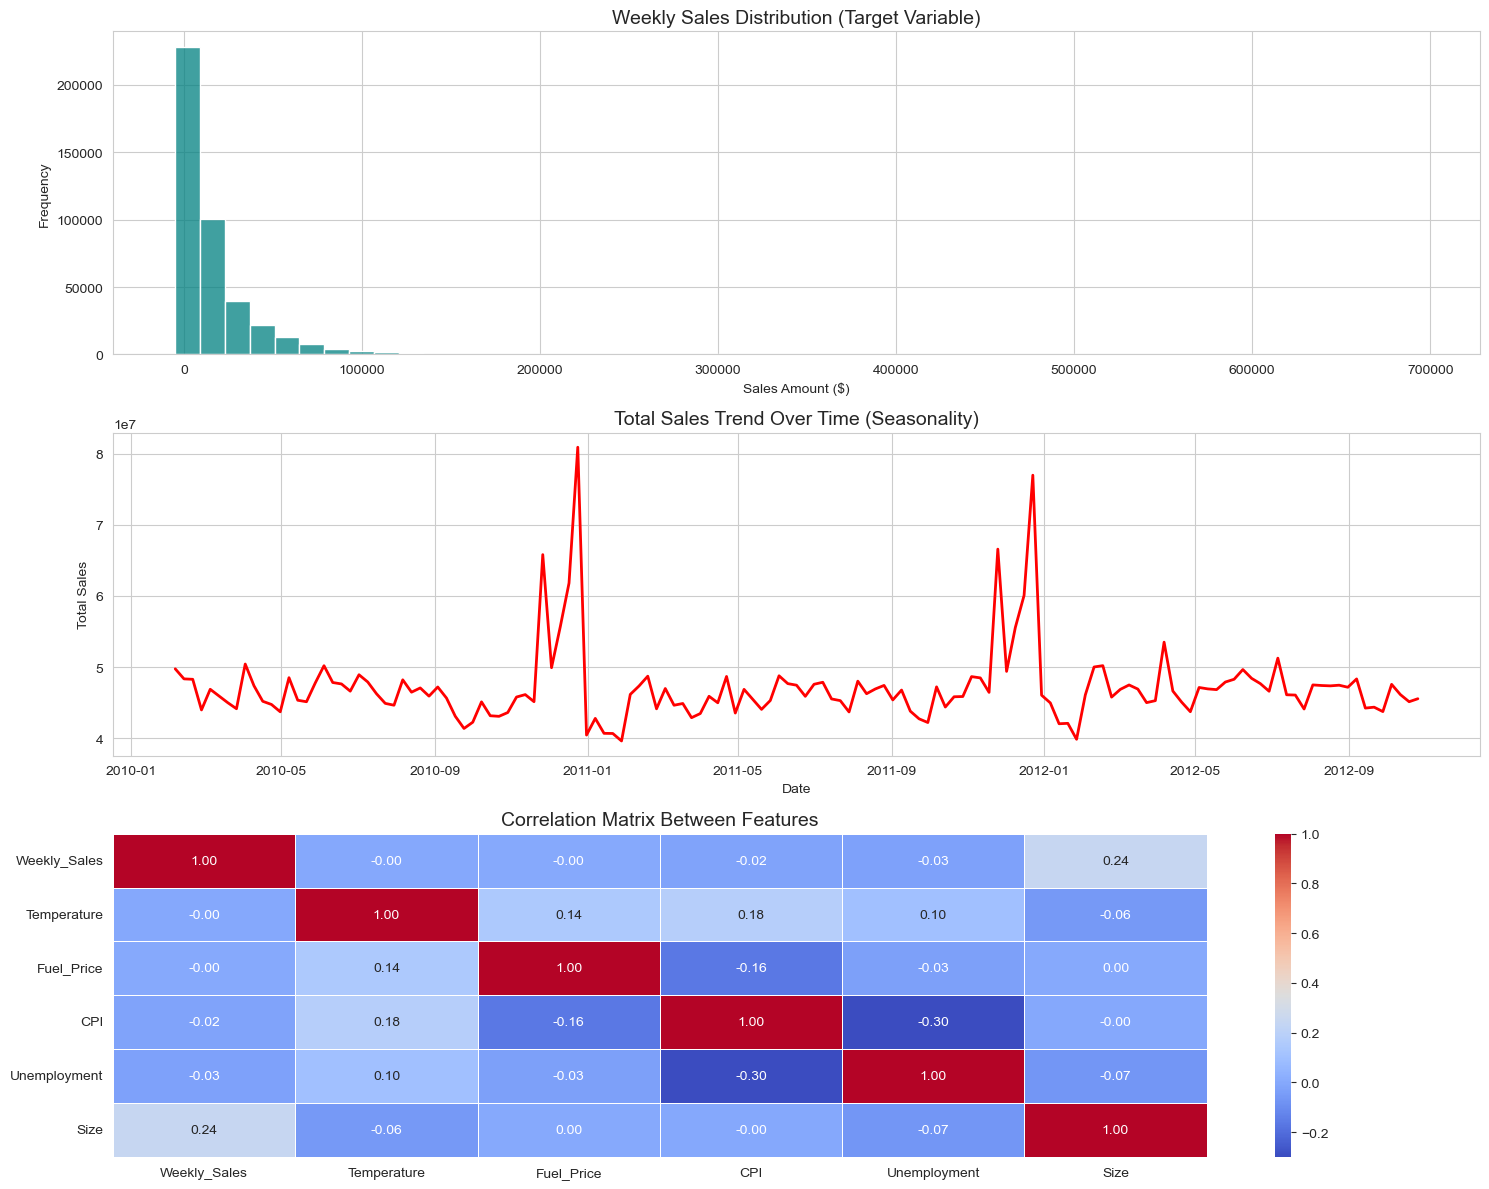

In [7]:
# EDA (Exploratory Data Analysis)
plt.figure(figsize=(15, 12))

# Chart 1
plt.subplot(3, 1, 1)
sns.histplot(final_dp['Weekly_Sales'], bins=50, color='teal')
plt.title('Weekly Sales Distribution (Target Variable)', fontsize=14)
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')

# Chart 2
plt.subplot(3, 1, 2)
daily_sales = final_dp.groupby('Date')['Weekly_Sales'].sum().reset_index()
sns.lineplot(data=daily_sales, x='Date', y='Weekly_Sales', color='red', linewidth=2)
plt.title('Total Sales Trend Over Time (Seasonality)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales')

# Chart 3
plt.subplot(3, 1, 3)
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
corr_matrix = final_dp[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Between Features', fontsize=14)

plt.tight_layout()
plt.show()

In [8]:
features_cols = ['Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday']
X = final_dp[features_cols]
y = final_dp['Weekly_Sales']

X['IsHoliday'] = X['IsHoliday'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print("rmse: ", rmse, "mae: ", mae)

rmse:  21820.16156600479 mae:  14557.645835263827


In [12]:
# Extract date components into separate columns
final_dp['Year']  = final_dp['Date'].dt.year
final_dp['Month'] = final_dp['Date'].dt.month
final_dp['Week']  = final_dp['Date'].dt.isocalendar().week
final_dp['Day']   = final_dp['Date'].dt.day

# Function to categorize holiday types by specific dates
def get_holiday_type(row):
    if row['IsHoliday'] == 1:
        date_str = str(row['Date']).split(' ')[0]

        if date_str in ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']:
            return 1  # Super Bowl
        elif date_str in ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']:
            return 2  # Labor Day
        elif date_str in ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']:
            return 3  # Thanksgiving
        elif date_str in ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']:
            return 4  # Christmas
    return 0  # Not a Holiday

final_dp['Holiday_Type'] = final_dp.apply(get_holiday_type, axis=1)

# Encode store type as a numeric value (A=3, B=2, C=1)
type_mapping = {"A": 3, "B": 2, "C": 1}
final_dp['Type_Encoded'] = final_dp['Type'].map(type_mapping)

print(f"Columns: {final_dp.columns.tolist()}")
final_dp.head()

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Day', 'Holiday_Type', 'Type_Encoded']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Day,Holiday_Type,Type_Encoded
0,1,1,2010-02-05,24924.500,False,A,151315,42.310,2.572,0.000,0.000,0.000,0.000,0.000,211.096,8.106,2010,2,5,5,0,3
1,1,1,2010-02-12,46039.490,True,A,151315,38.510,2.548,0.000,0.000,0.000,0.000,0.000,211.242,8.106,2010,2,6,12,1,3
2,1,1,2010-02-19,41595.550,False,A,151315,39.930,2.514,0.000,0.000,0.000,0.000,0.000,211.289,8.106,2010,2,7,19,0,3
3,1,1,2010-02-26,19403.540,False,A,151315,46.630,2.561,0.000,0.000,0.000,0.000,0.000,211.320,8.106,2010,2,8,26,0,3
4,1,1,2010-03-05,21827.900,False,A,151315,46.500,2.625,0.000,0.000,0.000,0.000,0.000,211.350,8.106,2010,3,9,5,0,3


In [13]:
features_cols = [
    'Store', 'Dept', 'Type_Encoded', 'Size',                        # Store Characteristics
    'Week', 'Month', 'Year', 'Holiday_Type',                        # Time and Holiday
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',             # Economic Indicators
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5' # Promotions
]

X = final_dp[features_cols]
y = final_dp['Weekly_Sales']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=50, max_depth=20, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred = rf_model.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("Feature Engineering + Random Forest Results")
print(f"RMSE (Margin of Error):    ${rmse:.2f}")
print(f"MAE  (Absolute Error):     ${mae:.2f}")
print(f"Improvement over Baseline: ${21820 - rmse:.0f} better than baseline")

Feature Engineering + Random Forest Results
RMSE (Margin of Error):    $3748.79
MAE  (Absolute Error):     $1497.92
Improvement over Baseline: $18071 better than baseline


In [14]:
param_grid = {
    'n_estimators':     [50, 100, 200],  # Number of trees
    'max_depth':        [10, 20, None],  # Tree depth
    'min_samples_split': [2, 5, 10]      # Split rule
}

# Randomized Search Cross-Validation to find the best hyperparameters
rf_random = RandomizedSearchCV(
    estimator            = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions  = param_grid,
    n_iter               = 5,   # Try 5 different combinations
    cv                   = 3,   # 3-fold cross-validation
    verbose              = 2,
    random_state         = 42,
    n_jobs               = -1,
    scoring              = 'neg_root_mean_squared_error'  # Minimize error
)

rf_random.fit(X_train, y_train)

print(f"Best Parameters: {rf_random.best_params_}")

# Evaluate the best model
best_model  = rf_random.best_estimator_
y_pred_opt  = best_model.predict(X_test)
rmse_opt    = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f"Optimized RMSE: {rmse_opt:.2f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}
Optimized RMSE: 3722.07


In [16]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Linear models need scaled features unlike Random Forest
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

# Hyperparameters to tune (alpha controls regularization strength)
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Randomized Search Cross-Validation
linear_random = RandomizedSearchCV(
    estimator           = linear_model,
    param_distributions = param_grid,
    n_iter              = 5,
    cv                  = 3,
    verbose             = 2,
    random_state        = 42,
    n_jobs              = -1,
    scoring             = 'neg_root_mean_squared_error'
)

linear_random.fit(X_train, y_train)

print(f"Best Parameters: {linear_random.best_params_}")

# Evaluate the best model
best_linear_model = linear_random.best_estimator_
y_pred_linear     = best_linear_model.predict(X_test)
rmse_linear       = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print(f"Linear Model RMSE: {rmse_linear:.2f}")
print(f"Random Forest RMSE: {rmse_opt:.2f}")
print(f"Difference: {rmse_linear - rmse_opt:.2f} (higher = RF is better)")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'model__alpha': 10.0}
Linear Model RMSE: 21789.21
Random Forest RMSE: 3722.07
Difference: 18067.15 (higher = RF is better)


In [19]:
param_grid_xgb = {
    'n_estimators':     [300, 500, 700],       # XGBoost needs more trees than RF
    'max_depth':        [4, 6, 8],             
    'learning_rate':    [0.01, 0.05, 0.1],     
    'subsample':        [0.7, 0.8, 0.9],       
    'colsample_bytree': [0.7, 0.8, 1.0],       # % of features used per tree
    'min_child_weight': [1, 3, 5]              # Controls overfitting
}

xgb_random = RandomizedSearchCV(
    estimator           = XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions = param_grid_xgb,
    n_iter              = 20,   # Was 5 before — more search = better params
    cv                  = 3,
    verbose             = 2,
    random_state        = 42,
    n_jobs              = -1,
    scoring             = 'neg_root_mean_squared_error'
)

xgb_random.fit(X_train, y_train)

print(f"Best Parameters: {xgb_random.best_params_}")

best_xgb_model = xgb_random.best_estimator_
y_pred_xgb     = best_xgb_model.predict(X_test)
rmse_xgb       = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb        = mean_absolute_error(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"Random Forest RMSE: {rmse_opt:.2f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
XGBoost RMSE: 3231.83
Random Forest RMSE: 3722.07


           Model     RMSE      MAE
1        XGBoost 3231.830 1675.991
0  Random Forest 3722.066 1497.918


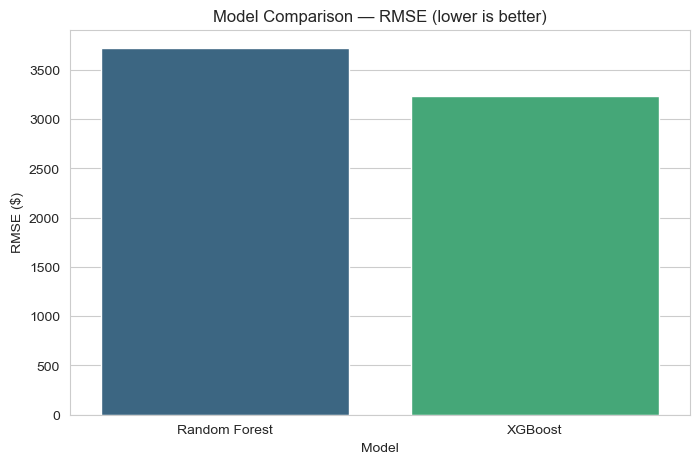

In [20]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE':  [rmse_opt, rmse_xgb],
    'MAE':   [mae, mae_xgb]
})

print(results.sort_values('RMSE'))

# Visualize comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='RMSE', data=results, palette='viridis')
plt.title('Model Comparison — RMSE (lower is better)')
plt.ylabel('RMSE ($)')
plt.show()

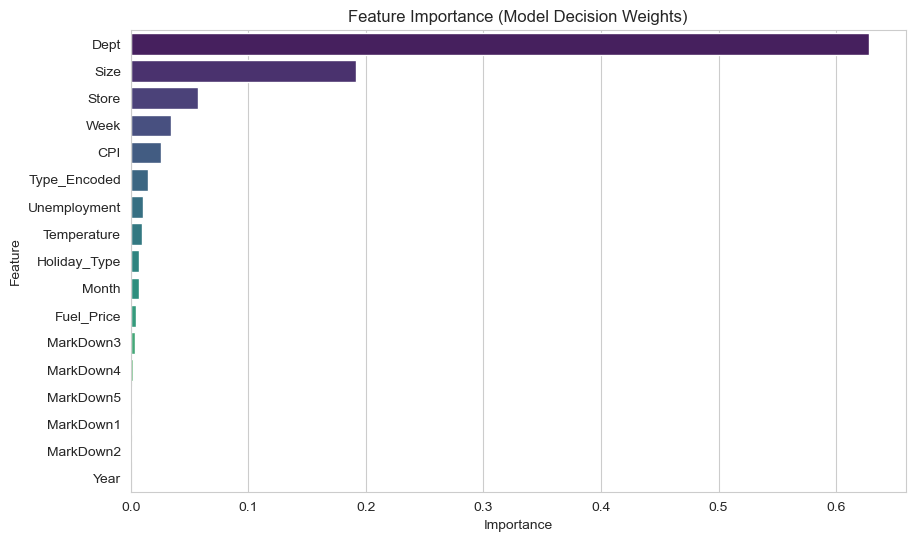

Final Model Saved: walmart_rf_model_optimized.pkl


In [15]:
import joblib

# Visualize feature importances — which inputs most influence the model's predictions
importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance (Model Decision Weights)')
plt.show()

# Save the trained model to disk
model_filename = 'walmart_rf_model_optimized.pkl'
joblib.dump(best_model, model_filename)
print(f"Final Model Saved: {model_filename}")

Original Train Row Count:  421570
Merged Final Row Count:    421570
Column Count:              22
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Random Forest RMSE: 3722.07  MAE: 1455.26
Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost RMSE: 3231.83  MAE: 1675.99
           Model     RMSE      MAE
1        XGBoost 3231.830 1675.991
0  Random Forest 3722.066 1455.257


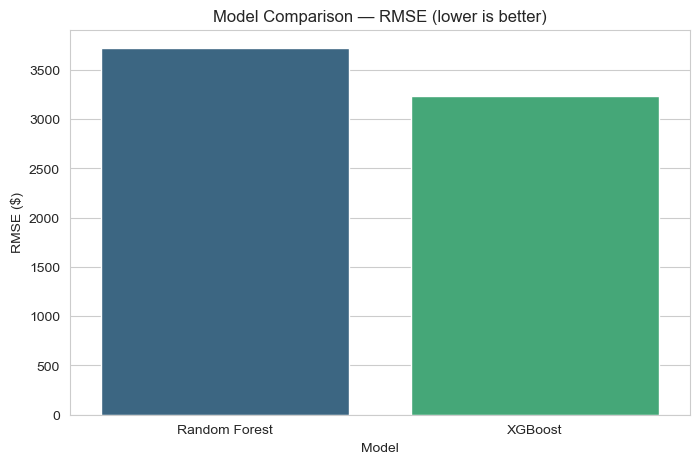

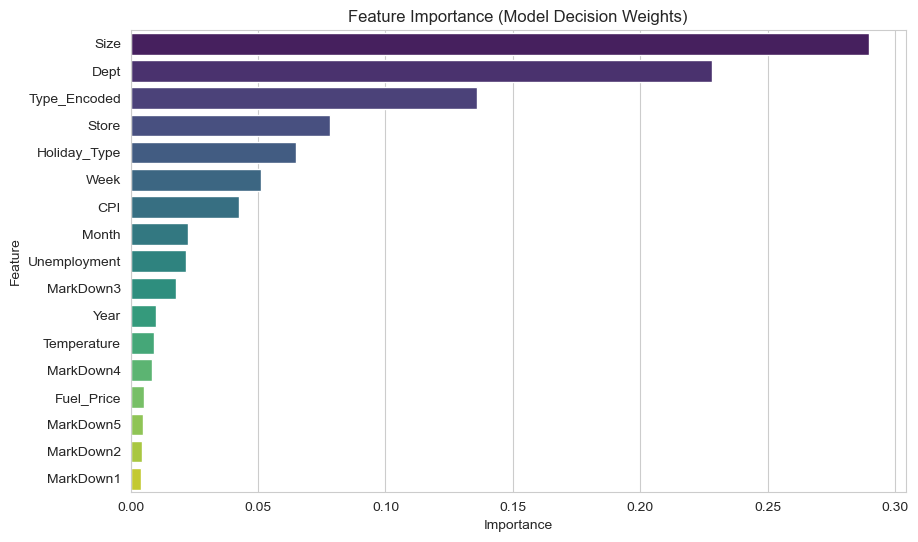

Models saved!
               Id  Weekly_Sales
0  1_1_2012-11-02     32539.842
1  1_1_2012-11-09     17877.723
2  1_1_2012-11-16     19133.547
3  1_1_2012-11-23     18667.805
4  1_1_2012-11-30     25413.939
5  1_1_2012-12-07     33423.203
6  1_1_2012-12-14     44194.457
7  1_1_2012-12-21     53906.641
8  1_1_2012-12-28     19784.896
9  1_1_2013-01-04     20169.086
/nSubmission saved — 115064 rows


In [21]:
import pandas as pd
import numpy as np
import zipfile
import io
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
zip_path = r"C:/Users/tyler/Downloads/walmart-recruiting-store-sales-forecasting.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    train    = pd.read_csv(io.BytesIO(z.read('train.csv.zip')),    compression='zip')
    features = pd.read_csv(io.BytesIO(z.read('features.csv.zip')), compression='zip')
    stores   = pd.read_csv(io.BytesIO(z.read('stores.csv')))
    test     = pd.read_csv(io.BytesIO(z.read('test.csv.zip')),     compression='zip')

# ── 2. MERGE & CLEAN ──────────────────────────────────────────────────────────
features_clean = features.drop(columns=['IsHoliday'])

def prepare_data(df):
    df = pd.merge(df, stores, on='Store', how='left')
    df = pd.merge(df, features_clean, on=['Store', 'Date'], how='left')
    df['Date'] = pd.to_datetime(df['Date'])
    df.fillna({'MarkDown1': 0, 'MarkDown2': 0, 'MarkDown3': 0,
               'MarkDown4': 0, 'MarkDown5': 0}, inplace=True)
    df['Year']  = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week']  = df['Date'].dt.isocalendar().week.astype(int)
    df['Day']   = df['Date'].dt.day
    df['Holiday_Type'] = df.apply(get_holiday_type, axis=1)
    df['Type_Encoded'] = df['Type'].map({"A": 3, "B": 2, "C": 1})
    return df

def get_holiday_type(row):
    if row['IsHoliday'] == 1:
        date_str = str(row['Date']).split(' ')[0]
        if date_str in ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']:
            return 1  # Super Bowl
        elif date_str in ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']:
            return 2  # Labor Day
        elif date_str in ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']:
            return 3  # Thanksgiving
        elif date_str in ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']:
            return 4  # Christmas
    return 0  # Not a Holiday

final_dp = prepare_data(train)
test     = prepare_data(test)

print(f"Original Train Row Count:  {train.shape[0]}")
print(f"Merged Final Row Count:    {final_dp.shape[0]}")
print(f"Column Count:              {final_dp.shape[1]}")

# ── 3. FEATURES & SPLIT ───────────────────────────────────────────────────────
features_cols = [
    'Store', 'Dept', 'Type_Encoded', 'Size',
    'Week', 'Month', 'Year', 'Holiday_Type',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]

X = final_dp[features_cols]
y = final_dp['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 4. RANDOM FOREST ──────────────────────────────────────────────────────────
rf_random = RandomizedSearchCV(
    estimator           = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]},
    n_iter=5, cv=3, verbose=2, random_state=42, n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)
rf_random.fit(X_train, y_train)
best_rf_model = rf_random.best_estimator_
y_pred_rf     = best_rf_model.predict(X_test)
rmse_rf       = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf        = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest RMSE: {rmse_rf:.2f}  MAE: {mae_rf:.2f}")

# ── 5. XGBOOST ────────────────────────────────────────────────────────────────
xgb_random = RandomizedSearchCV(
    estimator           = XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions = {'n_estimators': [300, 500, 700], 'max_depth': [4, 6, 8],
                           'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.7, 0.8, 0.9],
                           'colsample_bytree': [0.7, 0.8, 1.0], 'min_child_weight': [1, 3, 5]},
    n_iter=20, cv=3, verbose=2, random_state=42, n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)
xgb_random.fit(X_train, y_train)
best_xgb_model = xgb_random.best_estimator_
y_pred_xgb     = best_xgb_model.predict(X_test)
rmse_xgb       = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb        = mean_absolute_error(y_test, y_pred_xgb)
print(f"XGBoost RMSE: {rmse_xgb:.2f}  MAE: {mae_xgb:.2f}")

# ── 6. MODEL COMPARISON ───────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE':  [rmse_rf,  rmse_xgb],
    'MAE':   [mae_rf,   mae_xgb]
})
print(results.sort_values('RMSE'))

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='RMSE', data=results, palette='viridis')
plt.title('Model Comparison — RMSE (lower is better)')
plt.ylabel('RMSE ($)')
plt.show()

# ── 7. FEATURE IMPORTANCE ─────────────────────────────────────────────────────
importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': best_xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance (Model Decision Weights)')
plt.show()

# ── 8. SAVE MODELS ────────────────────────────────────────────────────────────
joblib.dump(best_rf_model,  'walmart_rf_model_optimized.pkl')
joblib.dump(best_xgb_model, 'walmart_xgb_model_optimized.pkl')
print("Models saved!")

# ── 9. SUBMISSION ─────────────────────────────────────────────────────────────
X_test_final = test[features_cols]
test_preds   = best_xgb_model.predict(X_test_final)

submission = pd.DataFrame({
    'Id':           test['Store'].astype(str) + '_' + test['Dept'].astype(str) + '_' + test['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': test_preds
})

submission.to_csv('C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/submissions/Walmart Recruiting - Store Sales Forecasting/submission.csv', index=False)
print(submission.head(10))
print(f"/nSubmission saved — {len(submission)} rows")

In [22]:
print('done')

done
